In [ ]:
import os
import glob
import numpy as np
import jax
import jax.numpy as jnp
from flax import linen as nn
import pennylane as qml
import optax
from torch.utils.data import Dataset, DataLoader # We use Torch's efficient loader
import matplotlib.pyplot as plt
import random

/Users/jaimanmunshi/miniconda3/envs/quantum/lib/python3.12/site-packages/pennylane/__init__.py:196: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.8.1 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [2]:
# ==========================================
# 1. CONFIGURATION & HYPERPARAMETERS
# ==========================================
DATA_PATH = "../Sen2Fire"
BATCH_SIZE = 8            # Paper used 8
LEARNING_RATE = 1e-4      # Paper used 1e-4
IMG_SIZE = 512            # Native size of Sen2Fire
EPOCHS = 3
FIRE_LOSS_MULTIPLIER = 5.0

In [3]:
# ==========================================
# 2. DATA LOADER (Specific to Sen2Fire)
# ==========================================
# ==========================================
# 2.1. DATASET SPLIT BY SCENE
# ==========================================
def get_scene_files(root_dir, scene_names):
    files = []
    for scene in scene_names:
        scene_dir = os.path.join(root_dir, scene)
        files.extend(glob.glob(os.path.join(scene_dir, "*.npz")))
    return files

class Sen2FireDataset(Dataset):
    def __init__(self, file_list):
        self.files = file_list
        print(f"Found {len(self.files)} files.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        # ...existing code...
        # (same as your previous __getitem__ implementation)
        data = np.load(self.files[idx])
        img = data['image']
        mask = data['label']
        if img.shape[0] < img.shape[1]:
            img = np.transpose(img, (1, 2, 0))
        indices = [11, 7, 3]
        if img.shape[-1] > 11:
            img = img[:, :, indices]
        else:
            img = img[:, :, :3]
        img = img.astype(np.float32) / 10000.0
        img = np.clip(img, 0, 1)
        mask = mask.astype(np.float32)
        if len(mask.shape) == 2:
            mask = np.expand_dims(mask, axis=-1)
        return img, mask

# Prepare file lists for each split
train_files = get_scene_files(DATA_PATH, ["scene1", "scene2"])
val_files = get_scene_files(DATA_PATH, ["scene3"])
test_files = get_scene_files(DATA_PATH, ["scene4"])

train_dataset = Sen2FireDataset(train_files)
val_dataset = Sen2FireDataset(val_files)
test_dataset = Sen2FireDataset(test_files)

# Helper to collate batch for JAX
def numpy_collate(batch):
    if isinstance(batch[0], np.ndarray):
        return np.stack(batch)
    elif isinstance(batch[0], (tuple,list)):
        transposed = zip(*batch)
        return [numpy_collate(samples) for samples in transposed]
    else:
        return np.array(batch)

Found 1458 files.
Found 504 files.
Found 504 files.


In [4]:
# ==========================================
# 3. QUANTUM LAYER (Bottleneck)
# ==========================================
n_qubits = 4
n_layers = 2
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="jax")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

class QuantumLayer(nn.Module):
    @nn.compact
    def __call__(self, x):
        weights = self.param('weights', nn.initializers.uniform(scale=0.1), (n_layers, n_qubits))
        # Vectorize over Batch, Height, Width
        q_node_vmap = jax.vmap(jax.vmap(jax.vmap(quantum_circuit, in_axes=(0, None)), in_axes=(0, None)), in_axes=(0, None))
        q_out = q_node_vmap(x, weights)
        return jnp.stack(q_out, axis=-1)

In [5]:
# ==========================================
# 4. DEEP HYBRID U-NET (512x512 -> 32x32)
# ==========================================
# We reuse the DoubleConv from previous step (with GroupNorm!)
class DoubleConv(nn.Module):
    out_channels: int
    @nn.compact
    def __call__(self, x):
        x = nn.Conv(self.out_channels, (3, 3), padding='SAME')(x)
        x = nn.GroupNorm()(x)
        x = nn.relu(x)
        x = nn.Conv(self.out_channels, (3, 3), padding='SAME')(x)
        x = nn.GroupNorm()(x)
        x = nn.relu(x)
        return x

class DeepHybridUNet(nn.Module):
    out_channels: int

    @nn.compact
    def __call__(self, x):
        # --- ENCODER (Contracting) ---
        # 512 -> 256
        c1 = DoubleConv(32)(x)
        p1 = nn.max_pool(c1, window_shape=(2, 2), strides=(2, 2))
        
        # 256 -> 128
        c2 = DoubleConv(64)(p1)
        p2 = nn.max_pool(c2, window_shape=(2, 2), strides=(2, 2))

        # 128 -> 64
        c3 = DoubleConv(128)(p2)
        p3 = nn.max_pool(c3, window_shape=(2, 2), strides=(2, 2))

        # 64 -> 32
        c4 = DoubleConv(256)(p3)
        p4 = nn.max_pool(c4, window_shape=(2, 2), strides=(2, 2))

        # --- QUANTUM BOTTLENECK (at 32x32 resolution) ---
        # We are now at 32x32 size. This is safe for the quantum layer.
        
        # Compress features to 4 for the quantum circuit
        q_in = nn.Conv(4, (1, 1))(p4)
        q_in = nn.relu(q_in)
        
        # Run Quantum Circuit
        q_out = QuantumLayer()(q_in)
        q_out = nn.relu(q_out)
        
        # Expand back
        bottleneck = nn.Conv(512, (1, 1))(q_out)
        bottleneck = nn.relu(bottleneck)

        # --- DECODER (Expansive) ---
        # Up 1: 32 -> 64
        u1 = nn.ConvTranspose(256, (2, 2), strides=(2, 2), padding='SAME')(bottleneck)
        u1 = jnp.concatenate([u1, c4], axis=-1)
        c5 = DoubleConv(256)(u1)

        # Up 2: 64 -> 128
        u2 = nn.ConvTranspose(128, (2, 2), strides=(2, 2), padding='SAME')(c5)
        u2 = jnp.concatenate([u2, c3], axis=-1)
        c6 = DoubleConv(128)(u2)

        # Up 3: 128 -> 256
        u3 = nn.ConvTranspose(64, (2, 2), strides=(2, 2), padding='SAME')(c6)
        u3 = jnp.concatenate([u3, c2], axis=-1)
        c7 = DoubleConv(64)(u3)

        # Up 4: 256 -> 512
        u4 = nn.ConvTranspose(32, (2, 2), strides=(2, 2), padding='SAME')(c7)
        u4 = jnp.concatenate([u4, c1], axis=-1)
        c8 = DoubleConv(32)(u4)

        # Final Output
        return nn.Conv(self.out_channels, (1, 1))(c8)

In [ ]:
# ==========================================
# 5. TRAINING SETUP
# ==========================================


def visualize_prediction(model, params, dataset, idx=None):
    """
    Runs inference on a single image and plots the Input, Mask, and Prediction.
    If idx is None, shuffles the dataset and picks a random sample.
    """
    indices = list(range(len(dataset)))
    random.shuffle(indices)
    if idx is None:
        idx = indices[0]
    # 1. Get a sample
    img, mask = dataset[idx]
    x_input = jnp.expand_dims(img, axis=0) # Shape: (1, 512, 512, 3)
    
    # 2. Run Model
    logits = model.apply({'params': params}, x_input)
    
    # 3. Apply Sigmoid to get probabilities (0.0 to 1.0)
    probs = nn.sigmoid(logits)
    
    # 4. Convert to Binary Prediction (> 0.5 is Fire)
    pred_mask = (probs > 0.5).astype(jnp.float32)
    
    # --- PLOTTING ---
    # We need to pull data back to CPU for plotting
    img_display = np.array(img)
    true_mask_display = np.array(mask).squeeze()
    pred_mask_display = np.array(pred_mask).squeeze()
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # A. Input Image (SWIR Composite)
    # We amplify the brightness slightly for visibility
    ax[0].imshow(np.clip(img_display * 2, 0, 1))
    ax[0].set_title("Input (SWIR Composite)")
    ax[0].axis('off')
    
    # B. Ground Truth Label
    ax[1].imshow(true_mask_display, cmap='gray')
    ax[1].set_title("Ground Truth Mask")
    ax[1].axis('off')
    
    # C. Model Prediction
    ax[2].imshow(pred_mask_display, cmap='magma')
    ax[2].set_title("Quantum Prediction")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_fire_sample(model, params, dataset):
    # 1. Shuffle indices and search for an image that actually has fire
    print("Searching for a sample with fire...")
    indices = list(range(len(dataset)))
    random.shuffle(indices)
    found_idx = -1
    for i in indices:
        _, mask = dataset[i]
        if np.sum(mask) > 10: # Threshold: at least 10 fire pixels
            found_idx = i
            break
    if found_idx == -1:
        print("No fire samples found in dataset subset!")
        return

    # 2. Run Visualization on that specific image
    print(f"Found fire at index {found_idx}. Running inference...")
    visualize_prediction(model, params, dataset, idx=found_idx)

def train_sen2fire():
    # 1. Setup Data
    # NOTE: You must set DATA_PATH to your actual download folder
    if not os.path.exists(DATA_PATH):
        print(f"Please download Sen2Fire data to {DATA_PATH} first!")
        return

    dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=numpy_collate)
    
    # 2. Setup Model
    model = DeepHybridUNet(out_channels=1)
    
    # Init params with dummy input
    dummy_x = jnp.ones((1, IMG_SIZE, IMG_SIZE, 3)) 
    key = jax.random.PRNGKey(0)
    variables = model.init(key, dummy_x)
    params = variables['params']
    
    # 3. Optimizer
    tx = optax.adam(learning_rate=LEARNING_RATE)
    opt_state = tx.init(params)
    
    # 4. Loss Function (Weighted for Class Imbalance)
    # Fire pixels are rare. We weight them higher.
    def loss_fn(params, x, y):
        logits = model.apply({'params': params}, x)
        # Sigmoid Cross Entropy
        loss = optax.sigmoid_binary_cross_entropy(logits, y)
        # Weight fire pixels (1) 5x more than background (0)
        weight = y * FIRE_LOSS_MULTIPLIER + (1 - y) * 1.0 
        return jnp.mean(loss * weight)

    @jax.jit
    def train_step(params, opt_state, x, y):
        loss, grads = jax.value_and_grad(loss_fn)(params, x, y)
        updates, new_opt_state = tx.update(grads, opt_state)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss

    # 5. Loop
    print(f"Starting training on Sen2Fire (SWIR Composite)...")
    
    for epoch in range(EPOCHS):
        for i, (x_batch, y_batch) in enumerate(dataloader):
            x_batch = jnp.array(x_batch)
            y_batch = jnp.array(y_batch)
            
            params, opt_state, loss = train_step(params, opt_state, x_batch, y_batch)
            
            print(f"Epoch {epoch} | Batch {i} | Loss: {loss:.4f}")
            
            if i % 10 == 0:
                # Visualize a random sample from the validation set
                # visualize_prediction(model, params, val_dataset, idx=None)
                visualize_fire_sample(model, params, val_dataset)

Starting training on Sen2Fire (SWIR Composite)...
Epoch 0 | Batch 0 | Loss: 0.8547
Searching for a sample with fire...
Found fire at index 2. Running inference...


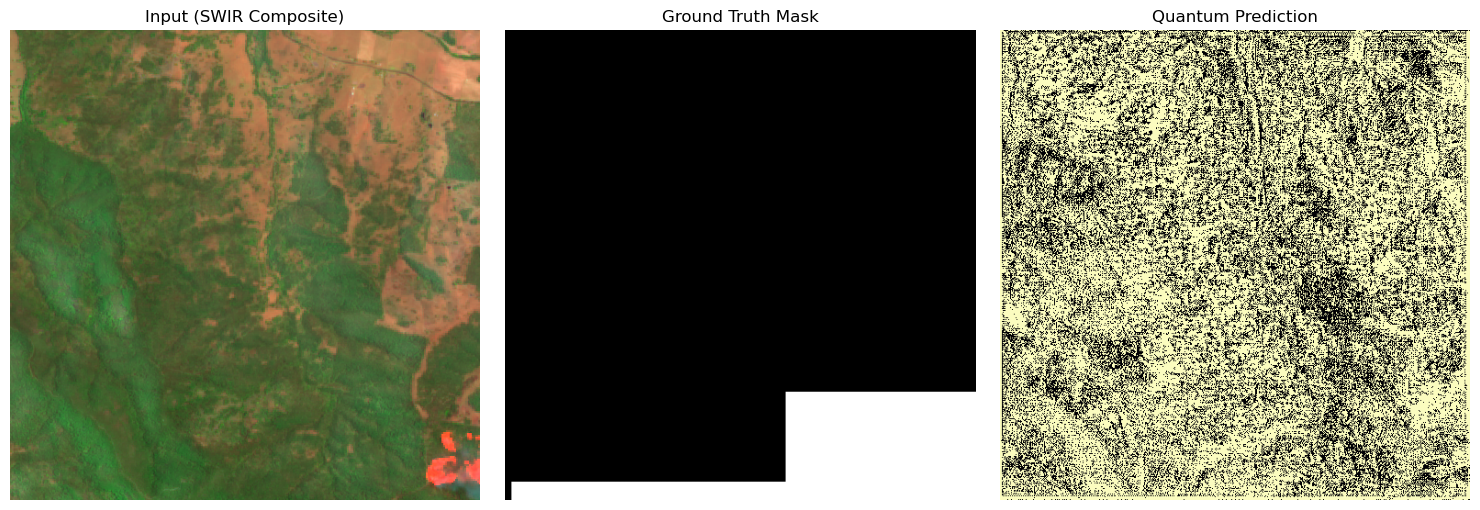

Epoch 0 | Batch 1 | Loss: 0.8215
Searching for a sample with fire...
Found fire at index 2. Running inference...


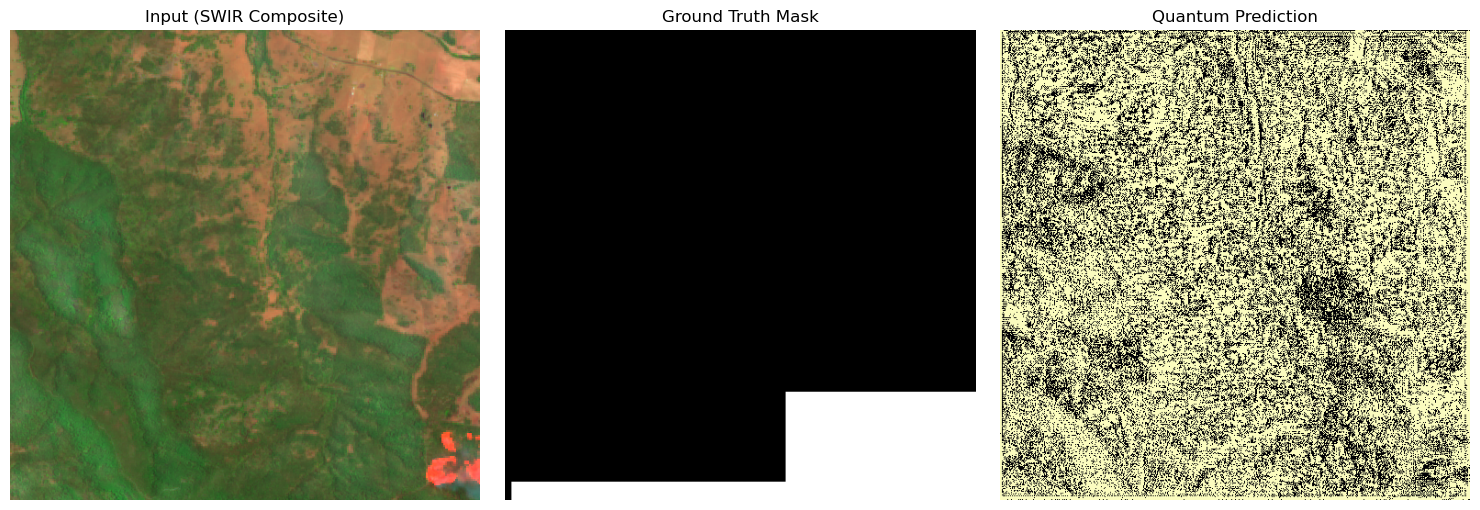

Epoch 0 | Batch 2 | Loss: 0.9441
Searching for a sample with fire...
Found fire at index 2. Running inference...


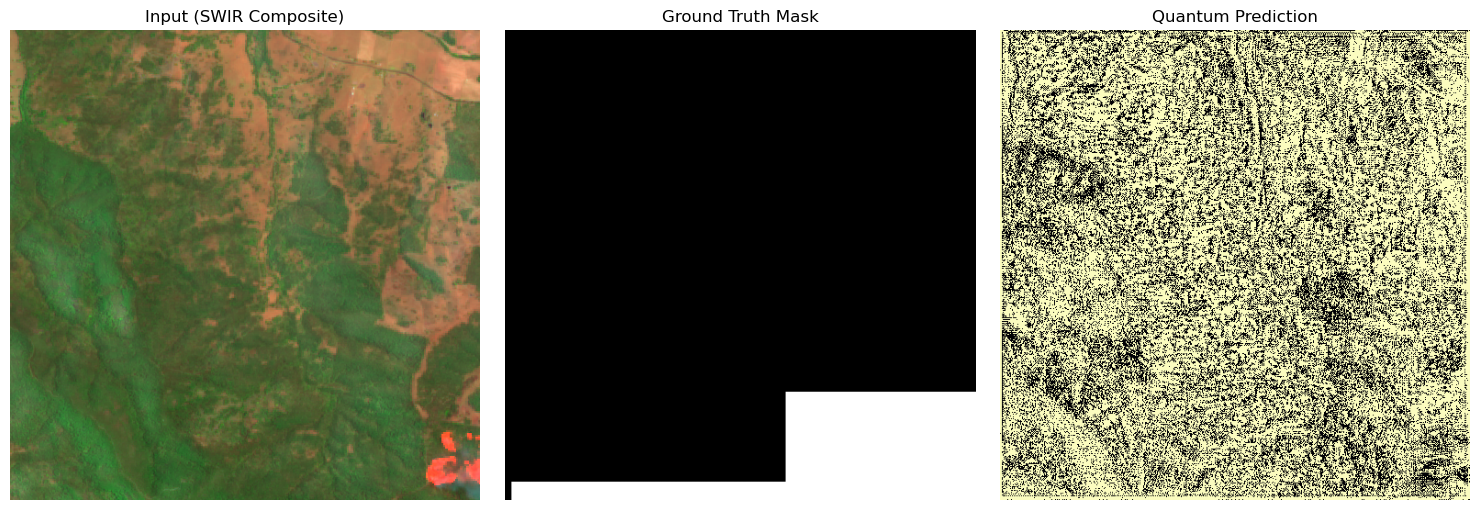

Epoch 0 | Batch 3 | Loss: 1.0999
Searching for a sample with fire...
Found fire at index 2. Running inference...


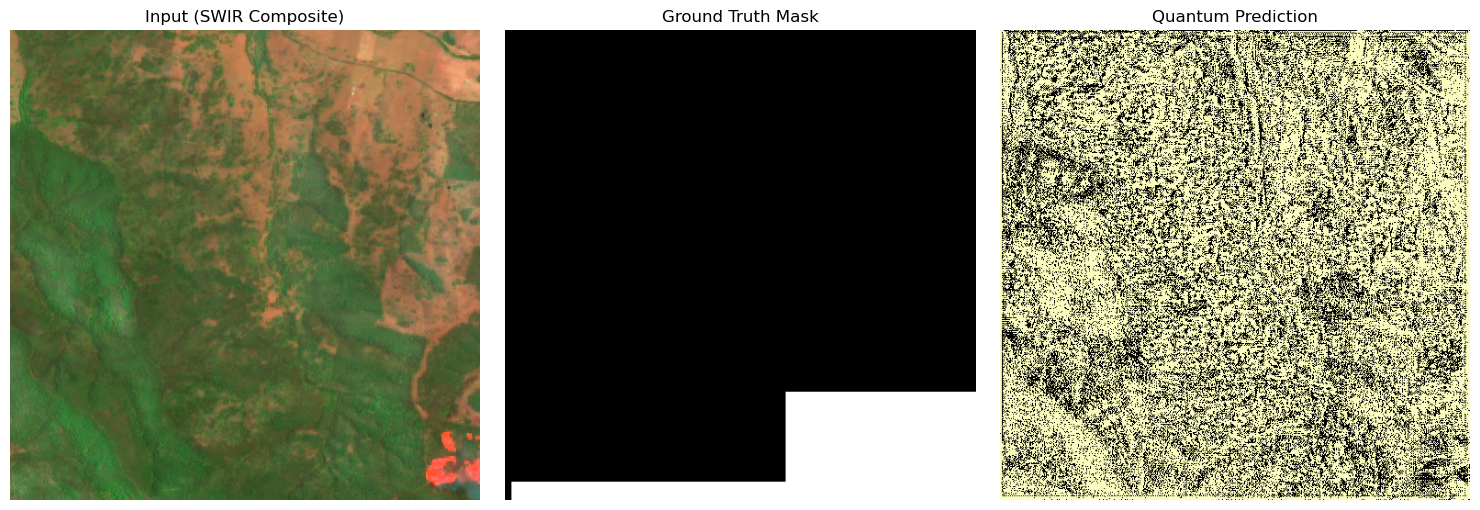

Epoch 0 | Batch 4 | Loss: 0.8061
Searching for a sample with fire...
Found fire at index 2. Running inference...


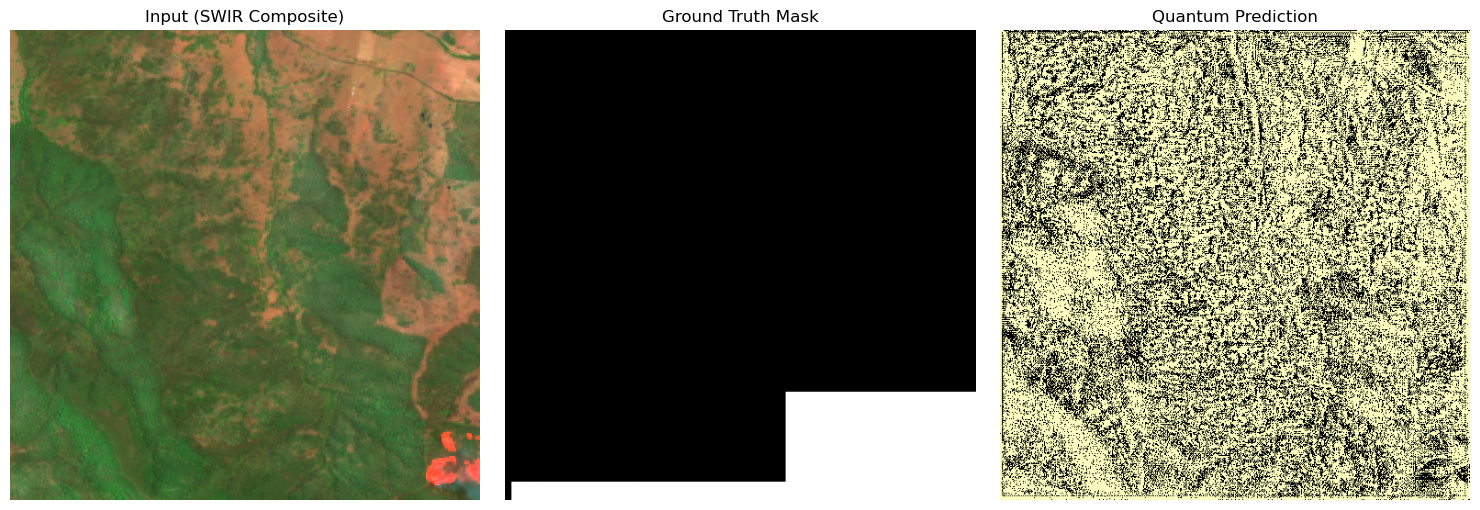

KeyboardInterrupt: 

In [9]:
train_sen2fire()